In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE

In [6]:
df = pd.read_csv("creditcard.csv")

In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [9]:
df.shape

(284807, 31)

In [10]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [12]:
df.duplicated().sum()

np.int64(1081)

In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [19]:
df["Class"].value_counts()

,count
Class,
0,283253
1,473


In [20]:
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.83329
1,0.16671


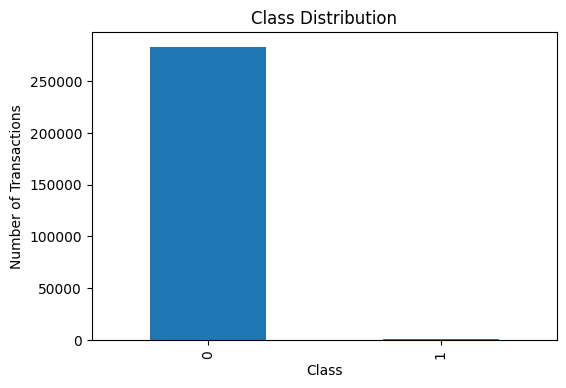

In [21]:
plt.figure(figsize=(6,4))

df["Class"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

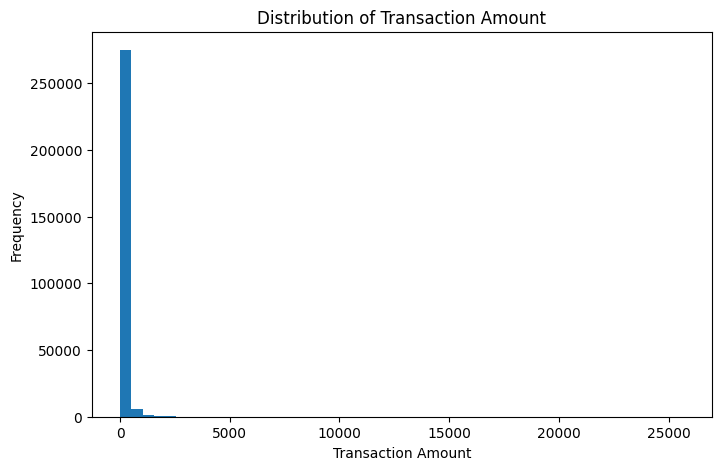

In [23]:
plt.figure(figsize=(8,5))
plt.hist(df["Amount"], bins=50)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df["Amount"] = scaler.fit_transform(df[["Amount"]])
df["Amount"].head()

,Amount
0,0.244200
1,-0.342584
2,1.158900
3,0.139886
4,-0.073813


In [26]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [27]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813


In [28]:
y.head()

,Class
0,0
1,0
2,0
3,0
4,0


In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (226980, 30)
Testing Set : (56746, 30)


In [31]:
print(y_train.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64


In [32]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [33]:
smote = SMOTE(random_state=42)

In [35]:
print(y_train_smote.value_counts())

Class
0    226602
1    226602
Name: count, dtype: int64


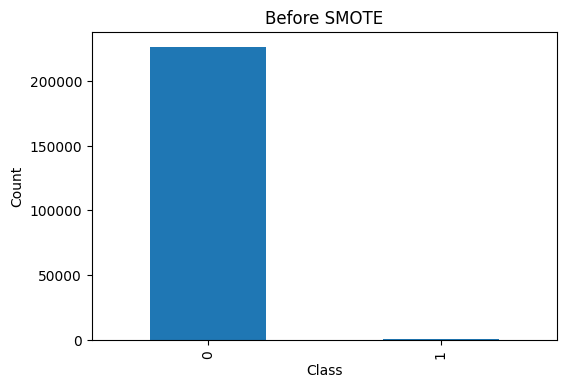

In [36]:
plt.figure(figsize=(6,4))
y_train.value_counts().plot(kind="bar")
plt.title("Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

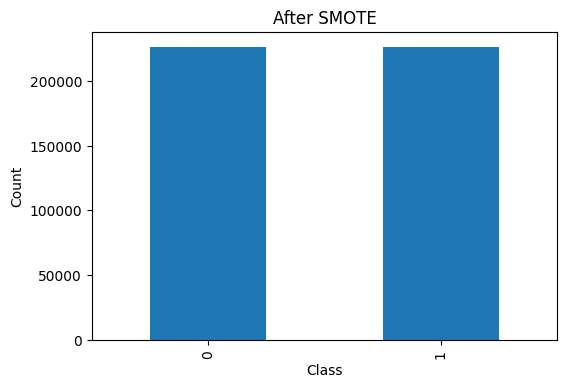

In [37]:
plt.figure(figsize=(6,4))
y_train_smote.value_counts().plot(kind="bar")
plt.title("After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [39]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [40]:
lr.fit(
    X_train_smote,
    y_train_smote
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [41]:
y_pred_lr = lr.predict(X_test)

In [42]:
y_prob_lr = lr.predict_proba(X_test)[:,1]

In [43]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    random_state=42
)

In [44]:
rf.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(random_state=42)

In [45]:
y_pred_rf = rf.predict(X_test)

In [46]:
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [47]:
from sklearn.metrics import confusion_matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

[[56106   545]
 [   14    81]]


In [48]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.13      0.85      0.22        95

    accuracy                           0.99     56746
   macro avg       0.56      0.92      0.61     56746
weighted avg       1.00      0.99      0.99     56746



In [49]:
precision_lr = precision_score(y_test, y_pred_lr)
print("Precision:", precision_lr)

Precision: 0.12939297124600638


In [50]:
recall_lr = recall_score(y_test, y_pred_lr)
print("Recall:", recall_lr)

Recall: 0.8526315789473684


In [51]:
roc_lr = roc_auc_score(y_test, y_prob_lr)
print("ROC-AUC:", roc_lr)

ROC-AUC: 0.9604289978622572


now for random forest

In [52]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[56644     7]
 [   22    73]]


In [53]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.77      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [54]:
precision_rf = precision_score(y_test, y_pred_rf)
print("Precision:", precision_rf)

Precision: 0.9125


In [55]:
recall_rf = recall_score(y_test, y_pred_rf)
print("Recall:", recall_rf)

Recall: 0.7684210526315789


In [56]:
roc_rf = roc_auc_score(y_test, y_prob_rf)
print("ROC-AUC:", roc_rf)

ROC-AUC: 0.9610929894859477


In [57]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "ROC-AUC": [roc_lr, roc_rf]
})

comparison

,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,0.129393,0.852632,0.960429
1,Random Forest,0.912500,0.768421,0.961093


In [58]:
from sklearn.model_selection import GridSearchCV

In [63]:
param_grid = {
    "n_estimators": [100],
    "max_depth": [10],
    "min_samples_split": [2, 5]
}

In [64]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=2
)

In [65]:
RandomForestClassifier(random_state=42)

RandomForestClassifier(random_state=42)

In [66]:
grid_search.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10], 'min_samples_split': [2, 5],
                         'n_estimators': [100]},
             scoring='roc_auc', verbose=2)

In [67]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [68]:
print("Best ROC-AUC Score:")
print(grid_search.best_score_)

Best ROC-AUC Score:
0.9998540040136543


In [69]:
best_rf = grid_search.best_estimator_

In [70]:
y_pred_best = best_rf.predict(X_test)

y_prob_best = best_rf.predict_proba(X_test)[:, 1]

In [71]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.60      0.83      0.70        95

    accuracy                           1.00     56746
   macro avg       0.80      0.92      0.85     56746
weighted avg       1.00      1.00      1.00     56746



In [72]:
print("Precision:", precision_score(y_test, y_pred_best))

Precision: 0.5984848484848485


In [73]:
print("Recall:", recall_score(y_test, y_pred_best))

Recall: 0.8315789473684211


In [74]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best))

ROC-AUC: 0.968409904038485


In [76]:
final_comparison = pd.DataFrame({
    "Model": ["Random Forest (Before Tuning)", "Random Forest (After Tuning)"],
    "Precision": [precision_rf, precision_score(y_test, y_pred_best)],
    "Recall": [recall_rf, recall_score(y_test, y_pred_best)],
    "ROC-AUC": [roc_rf, roc_auc_score(y_test, y_prob_best)]
})

final_comparison

,Model,Precision,Recall,ROC-AUC
0,Random Forest (Before Tuning),0.912500,0.768421,0.961093
1,Random Forest (After Tuning),0.598485,0.831579,0.968410
